In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
alessiocorrado99_animals10_path = kagglehub.dataset_download('alessiocorrado99/animals10')

print('Data source import complete.')


# Proyek Klasifikasi Gambar: [Animals]
- **Nama:** Irfan Maulana Hakim
- **Email:** irfanmaulanahakim04@gmail.com
- **ID Dicoding:** irfan1704

## Import Semua Packages/Library yang Digunakan

In [ ]:
# install library tambahan

!pip install tensorflowjs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.54.0 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
build 1.4.0 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
db-dtypes 1.5.0 requires pa

In [ ]:
import os
import random
import zipfile
import shutil
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
warnings.filterwarnings('ignore')

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau)

from sklearn.metrics import classification_report, confusion_matrix

2026-04-16 17:25:52.371228: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776360352.570612      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776360352.625836      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776360353.093595      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776360353.093634      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776360353.093638      55 computation_placer.cc:177] computation placer alr

In [ ]:
print('semua libary berhasil di import')
print(f' TensorFlow version: {tf.__version__}')
print(f'  GPU Available    : {tf.config.list_physical_devices("GPU")}')

semua libary berhasil di import
 TensorFlow version: 2.19.0
  GPU Available    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

In [ ]:
# lokasi dataset di Kaggle
base_path = '/kaggle/input/datasets/alessiocorrado99/animals10/raw-img'

# cek isi folder
class_dirs = sorted([
    d for d in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, d))])
print(f'Jumlah kelas : {len(class_dirs)}')
print(f'Kelas : {class_dirs}')

Jumlah kelas : 10
Kelas : ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


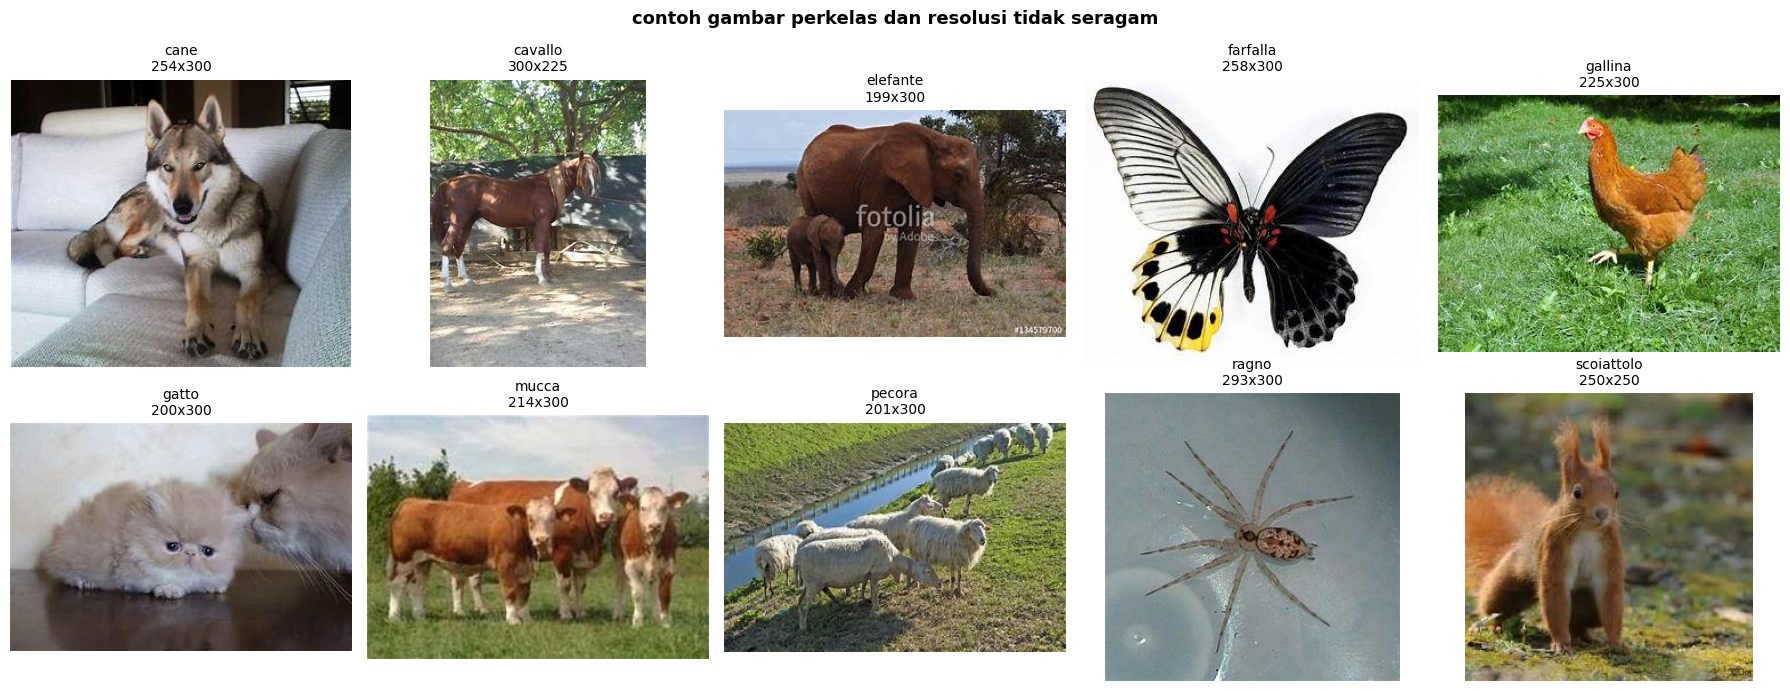

resolusi tiap gambar berbeda-beda


In [ ]:
# menampilkan 1 gambar dari setiap kelas

fig, axes = plt.subplots(2, 5, figsize=(18, 7)) # membuat grid plot 2 x 5
fig.suptitle('contoh gambar perkelas dan resolusi tidak seragam',
             fontsize=13, fontweight='bold')

for idx, class_name in enumerate(class_dirs): # iterasi setiap kelas beserta index nya
  class_path = os.path.join(base_path, class_name)
  sample_img = os.listdir(class_path)[0]
  img_path = os.path.join(class_path, sample_img)
  img = mpimg.imread(img_path)

  ax = axes[idx // 5][idx % 5] # menentukan posisi subplot berdasarkan index
  ax.imshow(img)
  ax.set_title(f'{class_name}\n{img.shape[0]}x{img.shape[1]}', fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()
print('resolusi tiap gambar berbeda-beda')

### Data Preprocessing

In [ ]:
import shutil

# copy dataset ke working directory dari read-only
# mendefinisikan path sumber dataset dari kaggle
src_path = '/kaggle/input/datasets/alessiocorrado99/animals10/raw-img'
base_path = '/kaggle/working/raw-img'

if not os.path.exists(base_path):
    shutil.copytree(src_path, base_path)
    print('dataset berhasil dicopy')
else:
    print('dataset tersedia')

#rename nama kelas dari Italia ke Inggris
translate = {
    'cane'       : 'dog',
    'cavallo'    : 'horse',
    'elefante'   : 'elephant',
    'farfalla'   : 'butterfly',
    'gallina'    : 'chicken',
    'gatto'      : 'cat',
    'mucca'      : 'cow',
    'pecora'     : 'sheep',
    'ragno'      : 'spider',
    'scoiattolo' : 'squirrel'}

for italian, english in translate.items(): # iterasi setiap nama kelas
    src = os.path.join(base_path, italian)
    dst = os.path.join(base_path, english)
    if os.path.exists(src):
        os.rename(src, dst)

CLASS_NAMES = sorted([ # mengambil daftar nama kelas yang sudah di rename
    d for d in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, d))])

print(f'CLASS_NAMES : {CLASS_NAMES}')

dataset tersedia
CLASS_NAMES : ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [ ]:
# konfig
IMG_SIZE = (224, 224) # ukuran gambar 224 piksel
BATCH_SIZE = 32 # jumlah gambar yg di proses dalam satu iterasi training
RANDOM_SEED = 42 # memastikan hasil random yang konsisten

In [ ]:
# augmentasi untuk data training
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 30,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest')

# validation dan test untuk rescale
val_test_datagen = ImageDataGenerator(rescale = 1./255)

print(f'IMG_SIZE  : {IMG_SIZE}')
print(f'BATCH_SIZE: {BATCH_SIZE}')

IMG_SIZE  : (224, 224)
BATCH_SIZE: 32


#### Split Dataset

In [ ]:
import shutil, os

# Hapus folder lama jika sudah ada
if os.path.exists('dataset_split'):
    shutil.rmtree('dataset_split')

# membuat folder baru train, val, dan test
DATASET_DIR = 'dataset_split'
for split in ['train', 'validation', 'test']:
    for class_name in CLASS_NAMES:
        os.makedirs(os.path.join(DATASET_DIR, split, class_name), exist_ok=True)

# copy dan split gambar
split_counts = {'train': 0, 'validation': 0, 'test': 0}

for class_name in CLASS_NAMES:
    class_path = os.path.join('/kaggle/working/raw-img', class_name)
    all_images = [
        f for f in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, f))]

    random.seed(42)
    random.shuffle(all_images)

    n = len(all_images)
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)

    train_imgs = all_images[:n_train]
    val_imgs   = all_images[n_train:n_train + n_val]
    test_imgs  = all_images[n_train + n_val:]

    for img in train_imgs: # copy gambar train ke folder train
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(DATASET_DIR, 'train', class_name, img))
    for img in val_imgs: # copy gambar validation ke folder validation
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(DATASET_DIR, 'validation', class_name, img))
    for img in test_imgs: # copy gambar test ke folder test
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(DATASET_DIR, 'test', class_name, img))

# menambahkan jumlah gambar ke counter masing-masing split
    split_counts['train']      += len(train_imgs)
    split_counts['validation'] += len(val_imgs)
    split_counts['test']       += len(test_imgs)

print(f'train : {split_counts["train"]} gambar')
print(f'validation : {split_counts["validation"]} gambar')
print(f'test  : {split_counts["test"]} gambar')
print(f'total : {sum(split_counts.values())} gambar')

train : 18322 gambar
validation : 3922 gambar
test  : 3935 gambar
total : 26179 gambar


## Modelling

In [ ]:
# membuat generator untuk train, val dan test

# generator untuk data training dengan augmentasi
train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, 'train'),
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical', # label dalam bentuk one hot encoding
    shuffle = True)

# generator untuk data validation tanpa augmentasi
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, 'validation'),
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical', # label dalam bentuk one hot encoding
    shuffle = False)

# generator untuk data test tanpa augmentasi
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, 'test'),
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical', # label dalam bentuk one hot encoding
    shuffle = False)

Found 18322 images belonging to 10 classes.
Found 3922 images belonging to 10 classes.
Found 3935 images belonging to 10 classes.


In [ ]:
# membuat model sequential, conv2d dan pooling layer
model = keras.Sequential([
    keras.layers.Input(shape=(*IMG_SIZE, 3)),

    # layer ke 1
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25), # menonaktif neuron 25% untuk mencegah overfitting

    # layer ke 2
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25), # menonaktif neuron 25% untuk mencegah overfitting

    # layer ke 3
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25), # menonaktif neuron 25% untuk mencegah overfitting

    # layer ke 4
    layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25), # menonaktif neuron 25% untuk mencegah overfitting

    # klasifikasi
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')],
    name='Animals10_CNN')

# kompilasi model dengan optimizer
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss  = 'categorical_crossentropy',
    metrics = ['accuracy']) # metriks yang dipantau selama training

I0000 00:00:1776360617.054118      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
# custom callback - berhenti saat akurasi mencapai >= 85%
class MyCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (logs.get('accuracy') >= 0.95 and
            logs.get('val_accuracy') >= 0.95):
            print('\nTarget 95% tercapai')
            self.model.stop_training = True # menghentikan proses training lebih awal

callbacks = [ # menyimpan model terbaik selama training berdasarkan val accuracy
    ModelCheckpoint(
        filepath = 'best_model.keras',
        monitor = 'val_accuracy',
        save_best_only = True,
        verbose = 1),

    EarlyStopping(
        monitor = 'val_accuracy',
        patience = 15, # jumlah epochs toleransi jika tidak ada perubahan
        restore_best_weights = True,
        verbose = 1),

    ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 5,
        min_lr = 1e-6, # batas minimum learning rate agar tidak terlalu kecil
        verbose = 1),

    MyCallback()
]

print('Callback siap digunakan')

Callback siap digunakan


In [ ]:
# training model
history = model.fit(
    train_generator,
    epochs = 100,
    validation_data = val_generator,
    callbacks = callbacks,
    verbose = 1)

Epoch 1/100


I0000 00:00:1776360632.867310     159 service.cc:152] XLA service 0x7bebf0003360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776360632.867358     159 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776360633.609892     159 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/573 ━━━━━━━━━━━━━━━━━━━━ 50s 88ms/step - accuracy: 0.0703 - loss: 3.7122   

I0000 00:00:1776360644.551389     159 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.2510 - loss: 2.5650
Epoch 1: val_accuracy improved from -inf to 0.41203, saving model to best_model.keras
573/573 ━━━━━━━━━━━━━━━━━━━━ 230s 375ms/step - accuracy: 0.2511 - loss: 2.5644 - val_accuracy: 0.4120 - val_loss: 1.8010 - learning_rate: 0.0010
Epoch 2/100
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.4188 - loss: 1.7455
Epoch 2: val_accuracy improved from 0.41203 to 0.45563, saving model to best_model.keras
573/573 ━━━━━━━━━━━━━━━━━━━━ 206s 360ms/step - accuracy: 0.4188 - loss: 1.7454 - val_accuracy: 0.4556 - val_loss: 1.6465 - learning_rate: 0.0010
Epoch 3/100
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.4590 - loss: 1.5911
Epoch 3: val_accuracy did not improve from 0.45563
573/573 ━━━━━━━━━━━━━━━━━━━━ 203s 354ms/step - accuracy: 0.4590 - loss: 1.5910 - val_accuracy: 0.3465 - val_loss: 2.3381 - learning_rate: 0.0010
Epoch 4/100
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5175 - loss: 1.

## Evaluasi dan Visualisasi

In [ ]:
test_loss, test_acc = model.evaluate(test_generator) # evaluasi peforma model dengan data testing
print(f'Test Accuracy: {test_acc:.2f}') # menampilkan hasil tset akurasi dengan format 2 angka desimal

123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.8920 - loss: 0.4106
Test Accuracy: 0.89


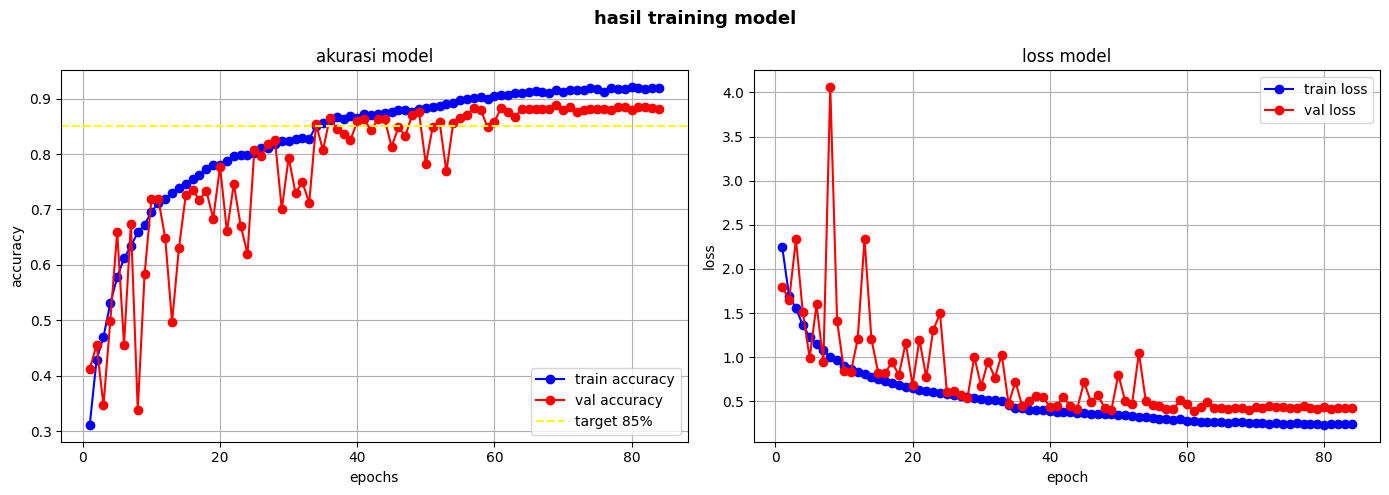

In [ ]:
# plot akurasi dan loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('hasil training model', fontsize=13, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

# plot akurasi
axes[0].plot(epochs_range,
             history.history['accuracy'],
             'b-o',
             label='train accuracy')

# plot val akurasi
axes[0].plot(epochs_range,
             history.history['val_accuracy'],
             'r-o',
             label='val accuracy')

# garis target akurasi 85%
axes[0].axhline(y=0.85,
               color='yellow',
               linestyle='--',
               label='target 85%')
axes[0].set_title('akurasi model')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('accuracy')
axes[0].legend()
axes[0].grid(True)

# plot loss
axes[1].plot(epochs_range,
            history.history['loss'],
             'b-o',
             label='train loss')
axes[1].plot(epochs_range,
            history.history['val_loss'],
            'r-o',
            label='val loss')
axes[1].set_title('loss model')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step


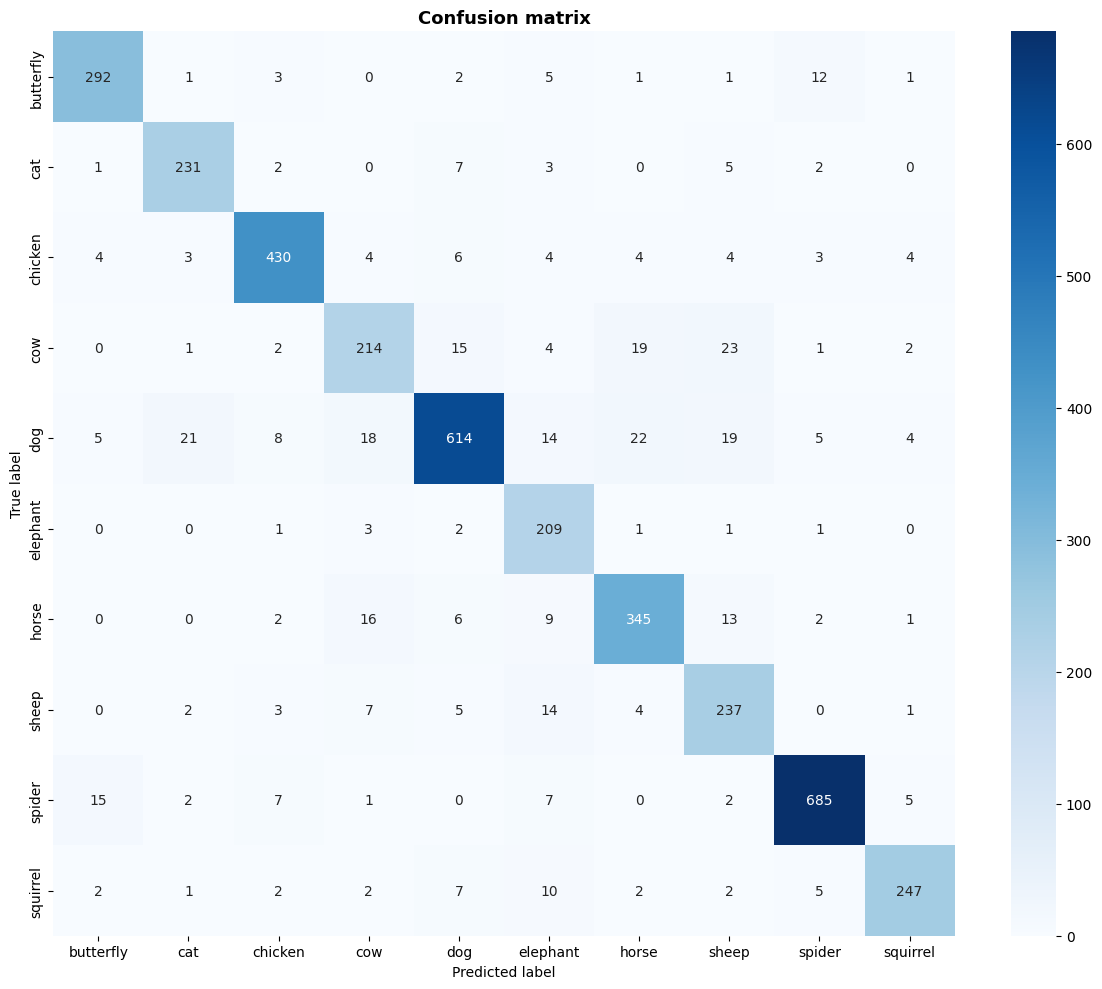

              precision    recall  f1-score   support

   butterfly       0.92      0.92      0.92       318
         cat       0.88      0.92      0.90       251
     chicken       0.93      0.92      0.93       466
         cow       0.81      0.76      0.78       281
         dog       0.92      0.84      0.88       730
    elephant       0.75      0.96      0.84       218
       horse       0.87      0.88      0.87       394
       sheep       0.77      0.87      0.82       273
      spider       0.96      0.95      0.95       724
    squirrel       0.93      0.88      0.91       280

    accuracy                           0.89      3935
   macro avg       0.87      0.89      0.88      3935
weighted avg       0.89      0.89      0.89      3935



In [ ]:
# confusion matrix
test_generator.reset() # reset generator, prediksi dimulai dari awal data test
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred) # membuat confusion matrix dari label asli dan prediksi sebelumnya

# membuat figure untuk menampilkan heatmap confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=CLASS_NAMES,
           yticklabels=CLASS_NAMES)
plt.title('Confusion matrix', fontsize=13, fontweight='bold')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

## Konversi Model

In [ ]:
# konversi model savedmodel
import tensorflowjs as tfjs

saved_model_path = '/kaggle/working/saved_model'
model.export(saved_model_path)
print(f'savedmodel berhasil disimpan di: {saved_model_path}')

INFO:tensorflow:Assets written to: /kaggle/working/saved_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/saved_model/assets


Saved artifact at '/kaggle/working/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136259112242256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136254526965712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136254526965904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136254526966864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256814038672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136254526966096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136254526967248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136254526967056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136254526963984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136254526964368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13

In [ ]:
# konversi model tf-lite
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

tflite_path = '/kaggle/working/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f'tf-lite berhasil disimpan di: {tflite_path}')
print(f'ukuran file: {os.path.getsize(tflite_path) / 1024 / 1024:.2f} MB')

W0000 00:00:1776379207.478644      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776379207.478679      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


tf-lite berhasil disimpan di: /kaggle/working/model.tflite
ukuran file: 201.95 MB


In [ ]:
# konversi model tfjs
tfjs_path = '/kaggle/working/tfjs_model'
tfjs.converters.convert_tf_saved_model(saved_model_path, tfjs_path)
print(f'tfjs berhasil disimpan di: {tfjs_path}')

I0000 00:00:1776379478.744172      55 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1776379478.744424      55 single_machine.cc:374] Starting new session
I0000 00:00:1776379478.745396      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


tfjs berhasil disimpan di: /kaggle/working/tfjs_model


## Inference (Optional)

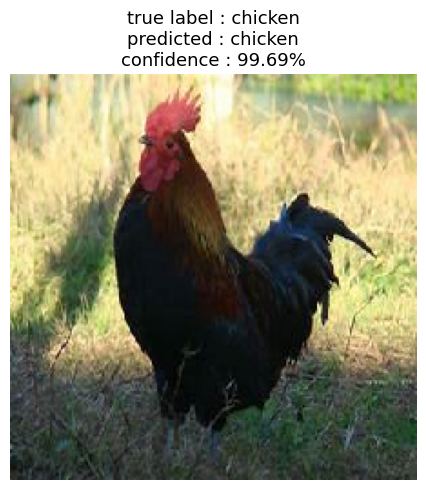

true label : chicken
predicted : chicken
confidence : 99.69%
hasil :benar


In [ ]:
# inferensi savedmodel

# load savedmodel yang sudah disimpan
loaded_model = tf.saved_model.load(saved_model_path)

# ambil fungsi inferensi dari savedmodel
infer = loaded_model.signatures['serving_default']

# ambil 1 gambar random dari test set
test_class = random.choice(CLASS_NAMES) # kelas random
test_class_path = os.path.join(DATASET_DIR, 'test', test_class)
test_img_name = random.choice(os.listdir(test_class_path)) # gambar random
test_img_path = os.path.join(test_class_path, test_img_name)

# load dan preprocessing gambar
img = tf.keras.utils.load_img(test_img_path, target_size=IMG_SIZE) # load gambar dan resize ke 224 x 224
img_array = tf.keras.utils.img_to_array(img) # ubah gambar menjadi array numpy
img_array = img_array / 255.0
img_array = tf.expand_dims(img_array,axis=0) # menambahkan dimensi batch menjadi(1, 224, 224, 3)
img_tensor = tf.cast(img_array, tf.float32) # mengubah tipe float32 sesuai input model

# inferensi
output = infer(img_tensor) # masukan gambar ke model
output_key = list(output.keys())[0]
predictions = output[output_key].numpy() # ambil hasil prediksi ke bentu numpy

# hasil prediksi
predicted_index = np.argmax(predictions[0]) # index kelas dengan probabilitas tinggi
predicted_class = CLASS_NAMES[predicted_index] # nama kelas hasil prediksi
confidence = predictions[0][predicted_index] * 100 # keyakinan model dalam persen

# tampilkan gambar dan hasil prediksi
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off') # sembunyikan axis
plt.title(
    f'true label : {test_class}\n'
    f'predicted : {predicted_class}\n'
    f'confidence : {confidence:.2f}%',
    fontsize=13)

plt.tight_layout()
plt.show()

print(f'true label : {test_class}')
print(f'predicted : {predicted_class}')
print(f'confidence : {confidence:.2f}%')
print(f'hasil :{"benar" if predicted_class == test_class else "salah"}')